Data Cleaning and Exploration
Indicated damage is the class label we want to predict

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
train_data = pd.read_csv('train.csv', header='infer')
print("Number of rows and columns in training data: ", train_data.shape)
train_data.head()
train_data.info()

/var/folders/j1/9v5pdr3x0yq9w6b8wmphvp2c0000gn/T/ipykernel_73242/1543053638.py:1: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv('train.csv', header='infer')


Number of rows and columns in training data:  (307178, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307178 entries, 0 to 307177
Data columns (total 55 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   INDEX_NR              307178 non-null  int64  
 1   INCIDENT_DATE         307178 non-null  object 
 2   INCIDENT_MONTH        307178 non-null  int64  
 3   INCIDENT_YEAR         307178 non-null  int64  
 4   TIME                  197926 non-null  object 
 5   TIME_OF_DAY           173207 non-null  object 
 6   AIRPORT_ID            307178 non-null  object 
 7   AIRPORT               307178 non-null  object 
 8   LATITUDE              266434 non-null  object 
 9   LONGITUDE             266431 non-null  object 
 10  RUNWAY                231593 non-null  object 
 11  STATE                 266434 non-null  object 
 12  FAAREGION             266434 non-null  object 
 13  LOCATION              39218 non-null   object

In [52]:
train_data.describe()

,INDEX_NR,INCIDENT_MONTH,INCIDENT_YEAR,EMA,EMO,AC_MASS,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,HEIGHT,SPEED,DISTANCE,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,TRANSFER,INDICATED_DAMAGE
count,3.071780e+05,307178.000000,307178.000000,204757.000000,194002.00000,219732.000000,219481.000000,219461.000000,204669.000000,12356.000000,3269.000000,152981.000000,95102.000000,203875.000000,307178.000000,307178.000000,307178.000000,307178.0,307178.000000
mean,1.030746e+06,7.221136,2013.629697,19.308815,8.15889,3.557770,2.004328,2.722128,2.546287,2.909922,2.162435,882.259627,142.973061,0.878159,0.000856,0.538925,0.179821,0.0,0.063569
std,3.851711e+05,2.750603,8.991125,10.573812,11.50024,0.865756,0.409663,2.117692,1.958387,1.938278,1.466136,1858.178379,46.550616,3.687059,0.029248,0.498483,0.384039,0.0,0.243984
min,6.082420e+05,1.000000,1990.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,7.054882e+05,5.000000,2008.000000,10.000000,1.00000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,8.052665e+05,8.000000,2015.000000,22.000000,4.00000,4.000000,2.000000,1.000000,1.000000,1.000000,1.000000,50.000000,140.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000
75%,1.437907e+06,9.000000,2021.000000,31.000000,10.00000,4.000000,2.000000,5.000000,5.000000,5.000000,4.000000,1000.000000,160.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000
max,1.825451e+06,12.000000,2026.000000,47.000000,97.00000,5.000000,4.000000,7.000000,7.000000,6.000000,5.000000,32000.000000,541.000000,99.000000,1.000000,1.000000,1.000000,0.0,1.000000


In [53]:
# Handling missing values
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
print("Number missing values for each column\n", null_column_totals)

Number missing values for each column
 BIRD_BAND_NUMBER        306465
ENG_4_POS               303909
ENROUTE_STATE           301832
PRECIPITATION           295966
ENG_3_POS               294822
LOCATION                267960
SPEED                   212076
NUM_SEEN                208546
SKY                     162825
FLT                     161435
HEIGHT                  154197
TIME_OF_DAY             133971
PHASE_OF_FLIGHT         120961
REG                     118982
AMO                     116813
EMO                     113176
TIME                    109252
DISTANCE                103303
COMMENTS                103083
ENG_2_POS               102509
EMA                     102421
AMA                      88896
TYPE_ENG                 87786
ENG_1_POS                87717
NUM_ENGS                 87697
AC_MASS                  87446
AC_CLASS                 87315
RUNWAY                   75585
LONGITUDE                40747
FAAREGION                40744
STATE                    40744


In [54]:
# remove any duplicates
print("Number of duplicate rows", train_data.duplicated().sum())
train_data.drop_duplicates()
# Shape of dataset remained the same, no duplicates found in training dataset

Number of duplicate rows 0


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307173,1786439,10/31/25,10,2025,,NaN,KVNC,VENICE MUNICIPAL AIRPORT,27.07161,-82.44033,...,NaN,1,Medium,NaN,NaN,FAA Form 5200-7-E,Carcass Found,1/2/26,0,0
307174,676049,8/20/06,8,2006,NaN,NaN,KORD,CHICAGO O'HARE INTL ARPT,41.9796,-87.90446,...,NaN,1,Small,NaN,2006-9-5-121657 /Legacy Record 237856/,FAA Form 5200-7-E,Carcass Found,11/16/06,0,0
307175,991735,5/31/19,5,2019,11:59,NaN,KTOA,ZAMPERINI FIELD ARPT,33.80338,-118.3396,...,NaN,1,Small,NaN,NaN,MOR,Tower,6/17/20,0,0
307176,1525457,6/22/20,6,2020,8:42,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,NaN,1,Small,NaN,NaN,FAA Form 5200-7-E,Carcass Found,5/20/24,0,0


In [55]:
# Drop columns that do not relate to prediction: remarks and comments
# Drop columns with less than 70% of row values filled
# BIRD_BAND_NUMBER        306465
# ENG_4_POS               303909
# ENROUTE_STATE           301832
# PRECIPITATION           295966
# ENG_3_POS               294822
# LOCATION                267961
# SPEED                   212076
# NUM_SEEN                208546
# WARNED                  191135
# SKY                     162825
# FLT                     161438
# HEIGHT                  154197
# TIME_OF_DAY             133971
# PHASE_OF_FLIGHT         120970
# REG                     118991
# AMO                     116813
# EMO                     113176
# TIME                    109252
# DISTANCE                103303
# COMMENTS                103083
# ENG_2_POS               102509
# EMA                     102421
print(train_data.shape)
# Drop columns with less than 70% of rows filled
train_data = train_data.drop(columns=["BIRD_BAND_NUMBER", "ENG_4_POS", "PRECIPITATION", "ENG_3_POS", "LOCATION", "SPEED", "NUM_SEEN", "WARNED", "SKY", "FLT", "HEIGHT", "TIME_OF_DAY", "PHASE_OF_FLIGHT", "REG", "AMO", "EMO", "TIME", "DISTANCE", "ENG_2_POS", "EMA", "AMA"])
print(train_data.shape)


# Drop Airports since AIRPORT is just name corresponding to AIRPORT_ID (reduce dimensionality)
train_data = train_data.drop(columns=["AIRPORT"])
# Drop LOCATION or standardize: many null values, inconsistent data format: FOUND AT KATL; DRO-DEN; Found KMEM; Waldorf, MD, 15 MILES KADW
# train_data = train_data.drop(columns=["LOCATION"])
# Drop OPERATOR since OPERATOR is name that corresponds to OPID (reduce dimensionality)
train_data = train_data.drop(columns=["OPERATOR"])
# Drop PRECIPITATION: MANYYY Empty values (Imputation may lead to incorrect results)
# train_data = train_data.drop(columns=["PRECIPITATION"])
# Drop BIRD_BAND_ID: Many empty values (Imputation may lead to incorrect results)
# train_data = train_data.drop(columns=["BIRD_BAND_ID"])
# Drop SPECIES: SPECIES_ID is corresponding ID for common name (SPECIES)
train_data = train_data.drop(columns=["SPECIES"])
# COMMENTS: just notes
train_data = train_data.drop(columns=["COMMENTS"])
# REMARKS: just notes
train_data = train_data.drop(columns=["REMARKS"])
# Drop Source: Type of report filed, may not be needed to predict indicated damage
train_data = train_data.drop(columns=["SOURCE"])
# Drop Person: Role of person who filed report, dont need for prediction
train_data = train_data.drop(columns=["PERSON"])
# Drop INDEX_NR: never use index as a feature value in the dataset
train_data = train_data.drop(columns=["INDEX_NR"])
# Drop INCIDENT_DATE: since we have INCIDENT_MONTH and INCIDENT_YEAR as well
train_data = train_data.drop(columns=["INCIDENT_DATE"])

# NOTE: we found that STATE and FAAREGION were correlated and when one was null, so was the other
# decided to remove FAAREGION 
state = train_data["STATE"].isnull()
faaregion = train_data["FAAREGION"].isnull()
shared_null = (state & faaregion).sum()
print(shared_null)
train_data = train_data.drop(columns=["FAAREGION"])


# FOR ENROUTE STATE: corresponding state column is typically empty, fill with ENROUTE STATE if present

(307178, 55)
(307178, 34)
40744


Data Exploration: Graphs

<Axes: xlabel='INDICATED_DAMAGE'>

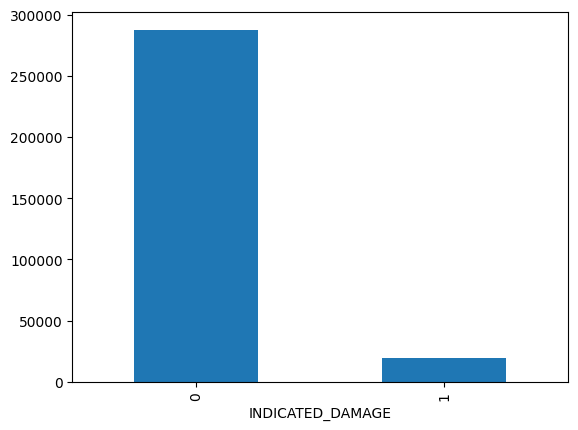

In [56]:
# This will display the distribution of the target variable, whether wildlife strike caused damage
# NOTES: this is an imbalanced distribution, we should not use accuracy as a metric and instead use confusion matrices
# With precision and recall to determine error
train_data["INDICATED_DAMAGE"].value_counts().plot.bar()

In [57]:
# Display the number of strikes based on state
train_data["STATE"].value_counts()

STATE
TX    27546
FL    22494
CA    21454
NY    14422
CO    13472
      ...  
MB       15
MH       12
NL        5
SK        5
NS        3
Name: count, Length: 67, dtype: int64

Determining Outliers using Box Plots

INCIDENT_MONTH             Axes(0.125,0.814746;0.133621x0.0652542)
INCIDENT_YEAR           Axes(0.285345,0.814746;0.133621x0.0652542)
AC_MASS                  Axes(0.44569,0.814746;0.133621x0.0652542)
NUM_ENGS                Axes(0.606034,0.814746;0.133621x0.0652542)
ENG_1_POS               Axes(0.766379,0.814746;0.133621x0.0652542)
OUT_OF_RANGE_SPECIES       Axes(0.125,0.736441;0.133621x0.0652542)
REMAINS_COLLECTED       Axes(0.285345,0.736441;0.133621x0.0652542)
REMAINS_SENT             Axes(0.44569,0.736441;0.133621x0.0652542)
TRANSFER                Axes(0.606034,0.736441;0.133621x0.0652542)
INDICATED_DAMAGE        Axes(0.766379,0.736441;0.133621x0.0652542)
dtype: object

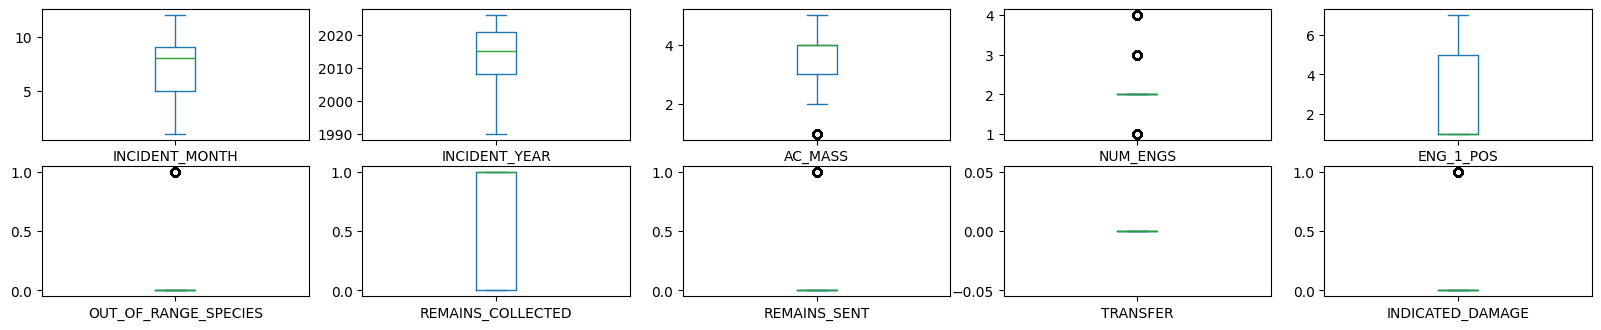

In [58]:
numeric_columns = train_data.select_dtypes(include='number')
numeric_columns.plot(kind='box', subplots=True, layout=(10, 5), figsize=(20,20))

Handling Missing Values

In [59]:
# Drop records that are missing NUM_STRUCK
data_pre_drop = train_data.shape[0]
train_data.dropna(axis=0, subset=['NUM_STRUCK'], inplace=True)
data_post_drop = train_data.shape[0]
num_dropped = data_pre_drop - data_post_drop
print("Dropped ", num_dropped, " records\n")


Dropped  647  records



In [60]:
# Handling missing values
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
null_column_totals

ENROUTE_STATE           301193
TYPE_ENG                 87716
ENG_1_POS                87649
NUM_ENGS                 87629
AC_MASS                  87387
AC_CLASS                 87250
RUNWAY                   75431
LONGITUDE                40728
LATITUDE                 40725
STATE                    40725
SIZE                     33449
REMAINS_COLLECTED            0
TRANSFER                     0
LUPDATE                      0
NUM_STRUCK                   0
REMAINS_SENT                 0
INCIDENT_MONTH               0
OUT_OF_RANGE_SPECIES         0
SPECIES_ID                   0
INCIDENT_YEAR                0
AIRCRAFT                     0
OPID                         0
AIRPORT_ID                   0
INDICATED_DAMAGE             0
dtype: int64

In [61]:
# Imputation for LATITUDE and LONGITUDE
# We found when imputing that the latitude and longitude has some errors in the data resulting in some entries to have commas which prevents us from calculating the mean
# Solution: drop records that contain invalid format
dms_count = train_data['LATITUDE'].astype(str).str.contains("°", na=False).sum()
total = len(train_data)
print(dms_count)

dms_count = train_data['LONGITUDE'].astype(str).str.contains("°", na=False).sum()
total_longitude = len(train_data)
print(dms_count)

# Drop records with latitude or longitude in DMS format
print(len(train_data))
train_data = train_data[~train_data['LATITUDE'].astype(str).str.contains("°", na=False)]
train_data = train_data[~train_data['LONGITUDE'].astype(str).str.contains("°", na=False)]
print(len(train_data))

train_data["LATITUDE"] = train_data["LATITUDE"].astype(str).str.replace(",", "")
train_data["LONGITUDE"] = train_data["LONGITUDE"].astype(str).str.replace(",", "")
train_data["LATITUDE"] = pd.to_numeric(train_data["LATITUDE"], errors="coerce")
train_data["LONGITUDE"] = pd.to_numeric(train_data["LONGITUDE"], errors="coerce")

print("Number of null values before imputation")
print(train_data["LATITUDE"].isnull().sum())
print(train_data["LONGITUDE"].isnull().sum())

train_data['LATITUDE'] = train_data['LATITUDE'].fillna(train_data['LATITUDE'].mean())
train_data['LONGITUDE'] = train_data['LONGITUDE'].fillna(train_data['LONGITUDE'].mean())

print("After imputation, check that no null values remain")
print(train_data["LATITUDE"].isnull().sum())
print(train_data["LONGITUDE"].isnull().sum())

4
1
306531
306527
Number of null values before imputation
40732
40727
After imputation, check that no null values remain
0
0


In [62]:
# If STATE is null, impute using ENROUTE_STATE, then remove ENROUTE_STATE column in the end
# Make a mask to show the records that enroute state has values for
# Make a mask for the records that STATE is null in
# Compute intersection between masks to get records that will be imputed with ENROUTE_STATE
# Fill missing STATE using ENROUTE_STATE
print("Pre fill: ", train_data["STATE"].isnull().sum())
train_data['STATE'] = train_data['STATE'].fillna(train_data['ENROUTE_STATE'])
print("Post fill: ", train_data["STATE"].isnull().sum())

# Drop ENROUTE_STATE
train_data = train_data.drop(columns=['ENROUTE_STATE'])

# Similar case imputation based on AIRPORT_ID since there is no null values present
print("Null entries before imputation", train_data["STATE"].isnull().sum(), "\n")
airport_states = train_data.groupby("AIRPORT_ID")["STATE"].transform("first")
train_data["STATE"] = train_data["STATE"].fillna(airport_states)
print("Null entries after imputation", train_data["STATE"].isnull().sum(), "\n")

# We have 11 remaining null entries, we can then drop those records with null states
train_data = train_data.dropna(subset=["STATE"])
print("Null entries after dropping remainder", train_data["STATE"].isnull().sum(), "\n")

# Standardize foreign STATE to only have one value (currently FN/FGN)
train_data["STATE"] = train_data["STATE"].replace("FN", "FGN")

Pre fill:  40725
Post fill:  35389
Null entries before imputation 35389 

Null entries after imputation 11 

Null entries after dropping remainder 0 



In [63]:
# Similar Case imputation for SIZE based on SPECIES_ID since we have no null values there
# However we found that this did not work, each null entry in SIZE corresponded with Unknown 
# Bird SPECIES (UNKB SPECIES_ID) which all contained null for size
size = train_data["SIZE"].isnull()
species_id = train_data["SPECIES_ID"].isnull()
shared_null_2 = (size & species_id).sum()
print(size.sum())
print(species_id.sum())
print(shared_null_2)

print("Null entries after imputation", train_data["SIZE"].isnull().sum(), "\n")
airport_sizes = train_data.groupby("SPECIES_ID")["SIZE"].transform(lambda x: x.mode())
train_data["SIZE"] = train_data["SIZE"].fillna(airport_sizes)
print("Null entries after imputation", train_data["SIZE"].isnull().sum(), "\n")

# Chose to impute null entries in SIZE with medium
train_data["SIZE"] = train_data["SIZE"].fillna("Medium")
print("Null entries after imputation", train_data["SIZE"].isnull().sum(), "\n")

33449
0
0
Null entries after imputation 33449 

Null entries after imputation 33449 

Null entries after imputation 0 



In [64]:
# Impute null values in RUNWAY
# RUNWAY - Runway designation where the strike occurred (blank if airborne).
# Null values exist but they have meaning (airborne)
print("Null entries after imputation", train_data["RUNWAY"].isnull().sum(), "\n")
train_data["RUNWAY"] = train_data["RUNWAY"].fillna("AIRBORNE")
print("Null entries after imputation", train_data["RUNWAY"].isnull().sum(), "\n")

Null entries after imputation 75421 

Null entries after imputation 0 



In [65]:
# AC_CLASS - Aircraft class (A = airplane, B = helicopter, C = glider, J = ultralight, Y = other).
print("Null entries after imputation", train_data["AC_CLASS"].isnull().sum(), "\n")
train_data["AC_CLASS"] = train_data["AC_CLASS"].fillna("U")
print("Null entries after imputation", train_data["AC_CLASS"].isnull().sum(), "\n")

Null entries after imputation 87250 

Null entries after imputation 0 



In [66]:
# AC_MASS - Aircraft weight class (1 = 2,250 kg or less through 5 = above 272,000 kg).
# Impute using mode
print("Null entries after imputation", train_data["AC_MASS"].isnull().sum(), "\n")
train_data["AC_MASS"] = train_data["AC_MASS"].fillna(train_data["AC_MASS"].mode()[0])
print("Null entries after imputation", train_data["AC_MASS"].isnull().sum(), "\n")


Null entries after imputation 87387 

Null entries after imputation 0 



In [67]:
# NUM_ENGS - Number of engines on the aircraft.
# Impute using median
print("Null entries after imputation", train_data["NUM_ENGS"].isnull().sum(), "\n")
train_data["NUM_ENGS"] = train_data["NUM_ENGS"].fillna(train_data["NUM_ENGS"].median())
print("Null entries after imputation", train_data["NUM_ENGS"].isnull().sum(), "\n")

Null entries after imputation 87629 

Null entries after imputation 0 



In [68]:
# ENG_1_POS - The mounting position of engine 1 on the aircraft.
# Impute using median
print("Null entries after imputation", train_data["ENG_1_POS"].isnull().sum(), "\n")
train_data["ENG_1_POS"] = train_data["ENG_1_POS"].fillna(train_data["ENG_1_POS"].median())
print("Null entries after imputation", train_data["ENG_1_POS"].isnull().sum(), "\n")

Null entries after imputation 87649 

Null entries after imputation 0 



In [69]:
# TYPE_ENG - The type of engine.
# Fill missing values with U for unknown
print("Null entries after imputation", train_data["TYPE_ENG"].isnull().sum(), "\n")
train_data["TYPE_ENG"] = train_data["TYPE_ENG"].fillna("U")
print("Null entries after imputation", train_data["TYPE_ENG"].isnull().sum(), "\n")

Null entries after imputation 87716 

Null entries after imputation 0 



In [70]:
# Check that all values have been correctly filled in
# Handling missing values
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
null_column_totals


INCIDENT_MONTH          0
NUM_ENGS                0
TRANSFER                0
LUPDATE                 0
SIZE                    0
NUM_STRUCK              0
REMAINS_SENT            0
REMAINS_COLLECTED       0
OUT_OF_RANGE_SPECIES    0
SPECIES_ID              0
ENG_1_POS               0
TYPE_ENG                0
INCIDENT_YEAR           0
AC_MASS                 0
AC_CLASS                0
AIRCRAFT                0
OPID                    0
STATE                   0
RUNWAY                  0
LONGITUDE               0
LATITUDE                0
AIRPORT_ID              0
INDICATED_DAMAGE        0
dtype: int64

Handling Categorical Features: One Hot Encoding

In [71]:
# need to one hot encode categorical variables
# categorical_columns =['NUM_STRUCK', 'TIME_OF_DAY', 'AIRPORT_ID', 'RUNWAY', 'STATE', 'FAAREGION', 'LOCATION', 'OPID', 'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SKY', 'SPECIES_ID', 'WARNED', 'SIZE', 'ENROUTE_STATE', 'SOURCE', 'PERSON']
categorical_columns =['NUM_STRUCK', 'AIRPORT_ID', 'RUNWAY', 'STATE', 'OPID', 'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 'SPECIES_ID']
train_data = pd.get_dummies(train_data, columns = categorical_columns, drop_first=True)


# WHAT TO ONE HOT ENCODE
# NUM_STRUCK, TIME_OF_DAY, AIRPORT_ID, RUNWAY, STATE, FAAREGION, LOCATION, OPID, AIRCRAFT, AC_CLASS, TYPE_ENG, PHASE_OF_FLIGHT, SKY, SPECIES_ID, 
# WARNED, SIZE, ENROUTE_STATE, SOURCE, PERSON

train_data.head()

,INCIDENT_MONTH,INCIDENT_YEAR,LATITUDE,LONGITUDE,AC_MASS,NUM_ENGS,ENG_1_POS,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,...,SPECIES_ID_ZY004,SPECIES_ID_ZY005,SPECIES_ID_ZY1,SPECIES_ID_ZY101,SPECIES_ID_ZY102,SPECIES_ID_ZY103,SPECIES_ID_ZY104,SPECIES_ID_ZY105,SPECIES_ID_ZY201,SPECIES_ID_ZZ201
0,12,1993,18.439420,-66.001830,4.0,3.0,5.0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
1,2,2010,2.745578,101.709917,4.0,3.0,1.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,5,2012,38.174390,-85.736000,4.0,2.0,1.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,10,2002,33.942540,-118.408070,4.0,2.0,1.0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
4,2,1997,21.975980,-159.338960,4.0,2.0,1.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


**Feature Engineering**

Combine AIRPORT_ID and RUNWAY

Combine NUM_STRUCK and SIZE

Create a feature based on NUM_STRUCK to check is multiple struck

Create a feature based on season of impact

In [73]:
# Create feature based on NUM_STRUCK and SIZE
# SIZE is a string value; map to numerical values to calculate severity of impact by multiplying SIZE * NUM_STRUCK
train_data["SIZE_NUM"] = train_data["SIZE"].map({
    "Small": 1,
    "Medium": 2,
    "Large": 3
})
# Calculate severity of impact by multiplying SIZE_NUM * NUM_STRUCK
train_data["SEVERITY"] = train_data["NUM_STRUCK"] * train_data["SIZE_NUM"]

In [ ]:
# Create feature based on AIRPORT_ID and RUNWAY